# Rapport de Projet : Open The Chests

**Groupe :**  
Damien LEGRAND,  
Marie DIDIER,  
Alexandre LAPRERIE,  
Thomas TEIXEIRA

**Cours :**  
CSC_5IA10_TA — Multi-Agent Games in Control  

## Introduction

Ce projet combine logique temporelle et contrôle robotique autour du problème *Open The Chests*. Un agent doit apprendre à reconnaître une séquence d'événements (couleurs de coffres) et à piloter un bras robotique KUKA pour ouvrir le bon coffre dans le bon ordre.

## Objectifs

- **Task 1 :** Maîtrise du bras KUKA — entraîner un agent RL à déplacer le bras vers une cible colorée.
- **Task 2 :** Reconnaissance de séquences d'événements — apprendre à identifier l'ordre correct des couleurs.
- **Task 3 :** Intégration *End-to-End* — combiner les deux modèles dans un pipeline complet.

---

## Tâche 1 : Contrôle du Bras Robotique (KUKA)

Dans cette première phase, nous abordons le problème du contrôle moteur d'un bras articulé au sein d'un moteur de physique PyBullet. L'objectif est d'entraîner un agent à atteindre un coffre cible parmi trois, en se basant sur des observations continues.  

### Formalisation de l'Environnement

Le problème est modélisé comme un Processus de Décision Markovien (MDP) défini par le triplet $(\mathcal{S}, \mathcal{A}, \mathcal{R})$ :
- Espace des États $\mathcal{S}$ : Le vecteur d'observation est de dimension 10. Il inclut les coordonnées de l'effecteur, les positions relatives des coffres, et un encodage one-hot de la couleur cible. 
- Espace des Actions $\mathcal{A}$ : L'action est continue et de dimension 3. Elle correspond aux déplacements incrémentaux $\Delta x, \Delta y, \Delta z$ de l'effecteur dans l'espace de travail.
- Fonction de Récompense ($\mathcal{R}$) : La récompense est hybride. Elle combine la distance euclidienne négative par rapport à la cible pour guider l'exploration le bonus de succès lors de la collision avec le coffre correct.


## Entrainement 

Pour résoudre cette tâche, nous avons utilisé l'algorithme PPO. L'architecture du réseau de neurones utilisée est une MlpPolicy composée de deux couches cachées de 64 neurones chacune. L'entraînement a été réalisé sur un horizon de 3 000 000 pas de temps pour garantir la convergence de la politique. Cet entrainement a été effectué sur le Cluster ENSTA pour gagner du temps. Voici ci-dessous la learning curve associé à cet entrainement (fichier `ModelV2_3M_epochs.zip`).

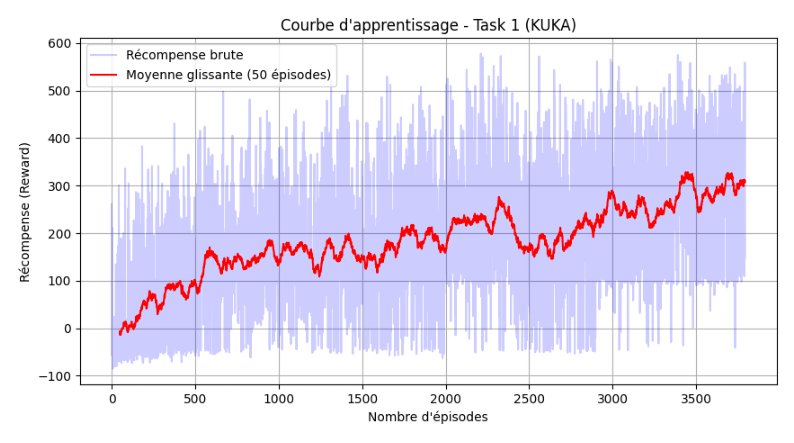

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread("assets_task_1/learning_curve.png")
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

On se rend compte que le reward moyen glissant au fil des epochs augmente, ce qui confirme que l'entrainement est effectué. A l'issu de cet entrainement, on obtient cependant un taux de réussite de 5 %. Voici un l'extrait d'une epoch avec ce modèle entrainé : 

In [ ]:
from IPython.display import Video
Video("assets_task_1/video_after_training.mp4", embed=True)



Le robot semble se rapprocher très vite de la boite, puis s'arréter devant avant de le toucher. On suppose que ceci est dû à la fonction qui est utilisé pour calculer les récompenses, qui donne un bonus au robot quand il ets proche de la boite. Ainsi, le robot préfère rester proche de la boite pour récupérer des récompenses, sans la touche car sinon, celle-ci s'arrêterait.

Une deuxième possibilité, qui est aussi probable, est qu'il aurait fallut continuer à faire tourner l'entrainement sur quelques millions d'itérations en plus. Cependant ce la représentait encore des heures de calculs en plus, donc nous avons préféré chercher une solution plus intelligente pour forcer la convergence. L'idée est de changer la fonction de récompense pour guider l'apprentissage.

Pour essayer d'obtenir de meilleurs performances, essayons de la modifier pour la rendre plus pertinente et plus précise. Nous allons implémenter la fonction de reward suivante : 

$$R_t = -1.0 \cdot \|d_t\| + 2.0 \cdot e^{-5.0 \|d_t\|} - 0.1 \cdot \Delta t + \mathbb{1}_{success} \cdot 1000.0$$
Cette nouvelle formulation repose sur trois piliers correctifs par rapport à la fonction par défaut :
- Le guidage exponentiel ($2.0 \cdot e^{-5.0 \|d_t\|}$) : Il a pour but de créer un puit de potentiel autour du coffre. Plus l'effecteur s'approche de la cible, plus le signal de récompense augmente de manière non linéaire, forçant l'agent à affiner sa précision terminale.
- La pénalité de temps ($-0.1 \cdot \Delta t$) : L'introduction d'un coût fixe de 0.1 à chaque pas de temps incite l'agent à minimiser la durée de l'épisode. Cela élimine les trajectoires hésitantes ou circulaires et favorise une planification de mouvement plus directe et efficiente.
- Un bonus élevé quand le robot gagne la partie pour ne pas qu'il se stabilise autout pour gagner des points sans interrompre la partie.

A partir de cette nouvelle Reward Function, nous avons relancé un entrainement sur 3 000 000 d'epochs. On obtient cette fois-ci un résultat beaucoup plus intéressant (fichier `ModelV2_3M_epochs.zip`). Voici la learning curve :

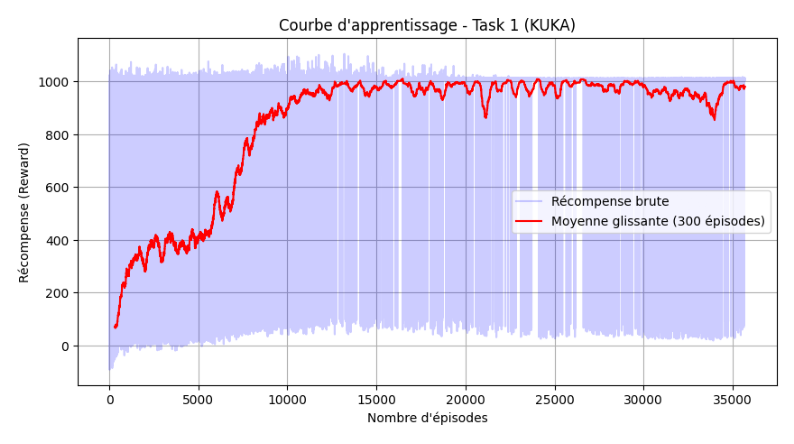

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread("assets_task_1/learning_curve_2.png")
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [16]:
from IPython.display import Video
Video("assets_task_1/video_after_training_2.mp4", embed=True)



---

## Tâche 2 

 Après avoir entraîné le modèle PPO  sur les trois niveaux de difficulté (v0, v1, v2), nous cherchons à vérifier si l'apprentissage se traduit par une organisation logique de ses représentations internes.

Pour ce faire, nous utilisons la technique du t-SNE (t-distributed Stochastic Neighbor Embedding). Cet algorithme de réduction de dimension permet de projeter les embeddings en 2D. Nous pourrons alors visualiser sa capacité de clustering : plus les groupes de couleurs sont nets et séparés, plus l'agent a une compréhension claire des spécificités de l'environnement.

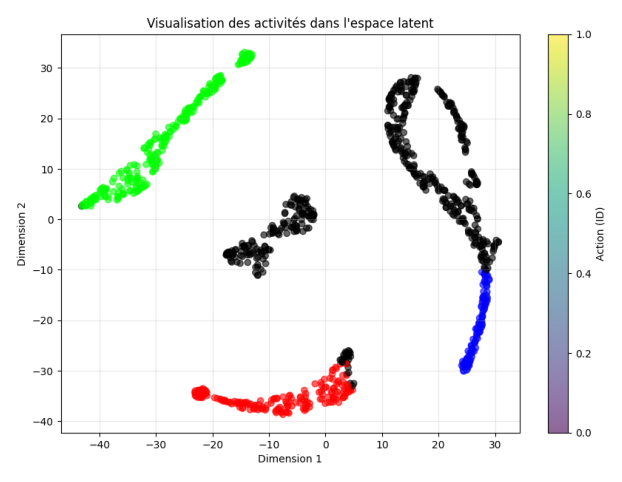

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread("assets_task_2/TSNE_v0.png")
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

**Niveau Facile** (v0) : Le modèle PPO parvient sans peine à séparer les états du jeu en clusters distincts. Chaque groupe de points correspond à une action spécifique et pertinente. Cette séparation nette prouve que le réseau de neurones a extrait les caractéristiques clés de l'environnement, permettant une réussite parfaite.

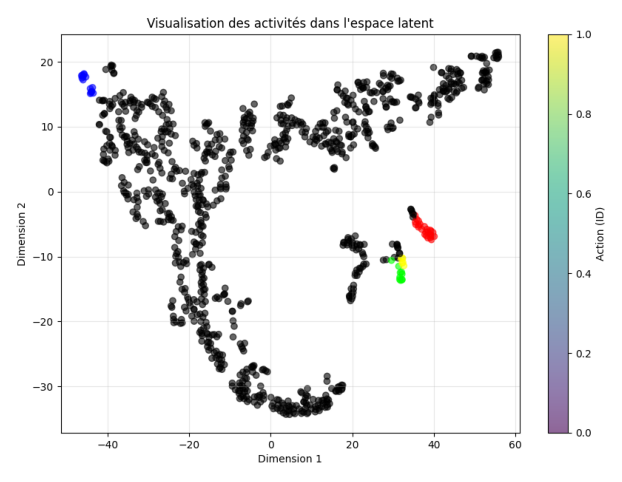

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread("assets_task_2/TSNE_v1.png")
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.show()


**Niveau Intermédiaire** (v1) : On observe un début de pollution de l'espace latent. Les frontières entre les clusters deviennent floues, ce qui traduit une confusion de l'agent face à des observations plus riches. L'accuracy diminue légèrement ce qui est signe que le modèle n'a plus une compréhension parfaite du lien entre l'environnement et le coffre qu'il doit ouvrir.

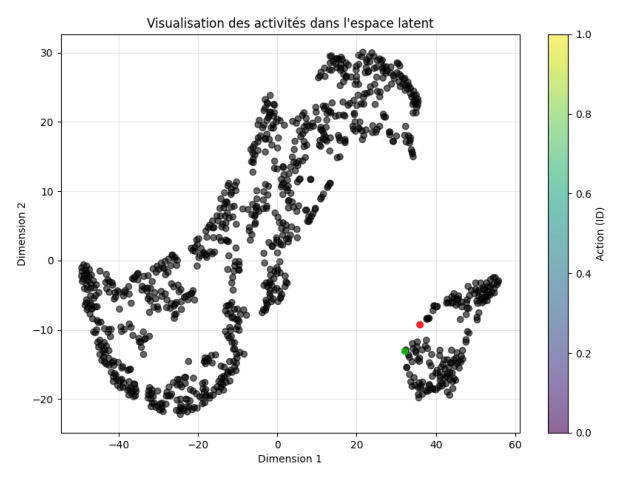

In [4]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
img = mpimg.imread("assets_task_2/TSNE_v2.png")
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.show()


**Niveau Difficile** (v2) : Le t-SNE révèle un échec total. La représentation est composée de points de la même couleur ce qui correspond que l'agent a choisi une seule action en boucle. Le modèle est tombé dans un optimum local : il répète la même action indéfiniment. Il n'a développé aucune compréhension sémantique de la tâche.

Le passage à un modèle capable de gérer la mémoire (comme le LSTM) ou des architectures plus modernes avec l'ajout de transformer paraît être la solution. Cela permettrait à l'agent non seulement de mieux explorer grâce à une meilleure gestion de l'incertitude (et donc de ne pas tomber trop souvent dans des minimums locaux), mais surtout d'avoir des emmbeddings plus riches en y intégrant la dimension temporelle, indispensable pour résoudre le niveau v2.

# Tâche 3 : Intégration complète (Stratégie et Contrôle)
Dans cette dernière étape, l'objectif a été de fusionner les deux modules développés précédemment. Nous avons mis en place une architecture où le modèle de logique (Open The Chests) sert de planificateur de haut niveau, tandis que le modèle de contrôle (KUKA) exécute les mouvements physiques.

### Approche par pipeline modulaire :

Nous avons séparé le problème en deux blocs distincts. D'un côté, modelOTC analyse les séquences d'événements pour identifier quel coffre doit être ouvert. De l'autre, modelKUKA reçoit l'index du coffre cible et gère les articulations du bras robotique dans PyBullet pour atteindre cette position. Cette structure permet de s'assurer que le bras peut atteindre n'importe quel coffre, peu importe la logique de jeu utilisée en amont.


In [3]:
import imageio
from IPython.display import Video, display
video_path = "assets_task_3/task3_execution.mp4"
display(Video(video_path, embed=True, width=600))

Lors de la phase de test de l'intégration, nous avons relevé un comportement répétitif de la part de l'agent. Le modèle choisit systématiquement le coffre 0 (Chest 0) pour ses actions. Ce résultat est assez particulier car, visuellement, nous avons bien vérifié que les couleurs des coffres changent à chaque nouvel essai, ce qui confirme que l'environnement Open The Chests génère bien des séquences différentes.

Ce blocage sur le premier coffre est très probablement lié aux difficultés rencontrées avec la version difficile (hard) du projet. La complexité des dépendances temporelles et la longueur des séquences d'événements semblent empêcher le modèle de converger vers une stratégie de reconnaissance efficace. En l'absence d'une compréhension claire de la séquence, l'agent semble avoir adopté une stratégie par défaut en ciblant toujours le même index.

Malgré cette limite dans la prise de décision logique, la communication entre les deux modèles est fonctionnelle : une fois qu'une cible est définie, le bras KUKA parvient à se déplacer précisément vers l'emplacement prévu, validant ainsi la robustesse de la partie contrôle moteur.